# 🇻🇳 EDA & Tiền xử lý — Vietnam Dataset (Transfer Learning)

**File nguồn:** `data/processed/VN_data/full_vietnam_monthly_merger.csv`  
**Mục tiêu:** Khám phá, tiền xử lý và feature engineering bộ dữ liệu Việt Nam  
để chuẩn bị cho quá trình **Transfer Learning** từ mô hình TFT đa quốc gia.

---
| Thông tin | Giá trị |
|---|---|
| Số dòng | 504 |
| Số cột gốc | 18 |
| Phạm vi thời gian | 2019-01 → 2024-12 (72 tháng) |
| Số series | 7 (Coal, Gas, Hydro, Other fossil, Solar, Wind, Total generation) |
| Missing values | **0** ✅ |
| Duplicates | **0** ✅ |
| Time gaps | **Không** ✅ |

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & CONFIG
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3f5c',
    'axes.labelcolor':  '#e0e0e0',
    'text.color':       '#e0e0e0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'grid.color':       '#2a2d3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#3a3f5c',
})

SERIES_COLORS = {
    'Coal':             '#ff7043',
    'Gas':              '#ffb74d',
    'Hydro':            '#4fc3f7',
    'Other fossil':     '#ce93d8',
    'Solar':            '#fff176',
    'Wind':             '#80deea',
    'Total generation': '#81c784',
}

DATA_PATH  = r'..\data\processed\VN_data\full_vietnam_monthly_merger.csv'
OUT_PATH   = r'..\data\processed\VN_data\vn_tft_ready.csv'

print('✅ Imports OK')

✅ Imports OK


---
## 1️⃣  Load & Tổng quan dữ liệu

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — LOAD DATA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

print('=' * 65)
print(f'  Shape           : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'  Date range      : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'  Months          : {df["date"].nunique()}')
print(f'  Series          : {df["series"].nunique()} — {sorted(df["series"].unique())}')
print(f'  Missing values  : {df.isnull().sum().sum()} ✅')
print(f'  Duplicates      : {df.duplicated(["series","date"]).sum()} ✅')
print('=' * 65)
print()
df.info()

  Shape           : 504 rows × 18 columns
  Date range      : 2019-01-01 → 2024-12-01
  Months          : 72
  Series          : 7 — ['Coal', 'Gas', 'Hydro', 'Other fossil', 'Solar', 'Total generation', 'Wind']
  Missing values  : 0 ✅
  Duplicates      : 0 ✅

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   entity                             504 non-null    object        
 1   date                               504 non-null    datetime64[ns]
 2   series                             504 non-null    object        
 3   is_aggregate_series                504 non-null    bool          
 4   generation_TWh                     504 non-null    float64       
 5   IPI_Value                          504 non-null    float64       
 6   CPI_Value                          504 non-null    float64    

In [15]:
# ── Thống kê sản lượng theo series ────────────────────────────────────────────
stats_table = df.groupby('series')['generation_TWh'].agg(['mean','std','min','max']).round(3)
stats_table['cv (%)'] = (stats_table['std'] / stats_table['mean'] * 100).round(1)
stats_table['zeros']  = df[df['generation_TWh']==0].groupby('series').size().reindex(stats_table.index, fill_value=0)
stats_table['is_aggregate'] = df.groupby('series')['is_aggregate_series'].first()
print('📊 Thống kê sản lượng generation_TWh theo series:')
print(stats_table.to_string())
print()
print('📌 Cột kinh tế & thời tiết có trong dataset:')
eco_cols = [c for c in df.columns if c not in ['entity','date','series','is_aggregate_series',
             'generation_TWh','humidity','precipitation','solar','temperature']]
weather_cols = ['humidity','precipitation','solar','temperature']
print('  Economic:', eco_cols)
print('  Weather :', weather_cols)

📊 Thống kê sản lượng generation_TWh theo series:
                    mean    std    min    max  cv (%)  zeros  is_aggregate
series                                                                    
Coal              10.255  2.141   6.45  17.08    20.9      0         False
Gas                2.634  0.810   1.13   4.31    30.8      0         False
Hydro              7.091  2.704   2.08  12.61    38.1      0         False
Other fossil       0.060  0.147   0.00   0.58   245.0     53         False
Solar              1.702  0.908   0.00   3.48    53.3      3         False
Total generation  22.238  2.725  16.11  28.59    12.3      0          True
Wind               0.496  0.458   0.00   1.84    92.3     10         False

📌 Cột kinh tế & thời tiết có trong dataset:
  Economic: ['IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price', 'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)', 'gas_price', 'castlecoal_price', 'castlecoal_vol']
  Weather : ['humidity', 'precipita

---
## 2️⃣  Phân tích vấn đề dữ liệu

In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 1: castlecoal_vol — string dạng '1.14K'
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🔴 VẤN ĐỀ 1 — castlecoal_vol có định dạng string ("1.14K")')
print(f'   dtype  : {df["castlecoal_vol"].dtype}')
print(f'   sample : {df["castlecoal_vol"].unique()[:8]}')
print()

# Parse: '1.14K' → 1140.0
def parse_k(val):
    if isinstance(val, str) and val.endswith('K'):
        return float(val[:-1]) * 1000
    return float(val)

df['castlecoal_vol_parsed'] = df['castlecoal_vol'].apply(parse_k)
print(f'   Sau parse: min={df["castlecoal_vol_parsed"].min():.0f}, '
      f'max={df["castlecoal_vol_parsed"].max():.0f}, '
      f'mean={df["castlecoal_vol_parsed"].mean():.0f}')
print('   ✅ Đã parse thành công về float')

🔴 VẤN ĐỀ 1 — castlecoal_vol có định dạng string ("1.14K")
   dtype  : object
   sample : ['1.14K' '0.88K' '0.55K' '0.68K' '0.14K' '0.43K' '1.08K' '0.13K']

   Sau parse: min=10, max=1860, mean=476
   ✅ Đã parse thành công về float


In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 2: FDI_Disbursed có giá trị âm (-0.5)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fdi_col = 'FDI_Disbursed_Monthly(bilionUSD)'
neg_fdi = df[df[fdi_col] < 0]
print('🔴 VẤN ĐỀ 2 — FDI_Disbursed_Monthly có giá trị âm')
print(f'   Số dòng âm : {len(neg_fdi)}')
print(f'   Giá trị min: {df[fdi_col].min()}')
print()
if len(neg_fdi):
    print('   Các tháng bị âm:')
    print(neg_fdi[['date','series', fdi_col]].drop_duplicates('date').to_string(index=False))
print()
print('   ➤ FDI âm có thể là điều chỉnh số liệu hồi tố (retroactive adjustment)')
print('   ➤ Cách xử lý: clip(0) hoặc dùng rolling mean để smooth')

🔴 VẤN ĐỀ 2 — FDI_Disbursed_Monthly có giá trị âm
   Số dòng âm : 7
   Giá trị min: -0.5

   Các tháng bị âm:
      date series  FDI_Disbursed_Monthly(bilionUSD)
2021-05-01   Coal                              -0.5

   ➤ FDI âm có thể là điều chỉnh số liệu hồi tố (retroactive adjustment)
   ➤ Cách xử lý: clip(0) hoặc dùng rolling mean để smooth


In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 3: ZEROS trong Solar & Wind (giai đoạn chưa triển khai)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🟡 VẤN ĐỀ 3 — ZEROS trong Solar và Wind')
for ser in ['Solar', 'Wind', 'Other fossil']:
    sub = df[df['series']==ser].sort_values('date')
    zeros = sub[sub['generation_TWh']==0]
    if len(zeros):
        print(f'   {ser}: {len(zeros)} zeros — tháng {zeros["date"].dt.strftime("%Y-%m").tolist()}')
    else:
        print(f'   {ser}: không có zero')
print()
print('   ➤ Solar/Wind zeros (2019) = chưa có công trình → dữ liệu ĐÚNG')
print('   ➤ Other fossil zeros (73%) = VN ít dùng → dữ liệu ĐÚNG')
print('   ➤ KHÔNG clip/remove — nhưng cần dùng softplus/log1p khi normalize')

🟡 VẤN ĐỀ 3 — ZEROS trong Solar và Wind
   Solar: 3 zeros — tháng ['2019-01', '2019-02', '2019-11']
   Wind: 10 zeros — tháng ['2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09', '2019-12', '2021-08']
   Other fossil: 53 zeros — tháng ['2019-01', '2019-03', '2019-04', '2019-07', '2019-09', '2019-11', '2020-04', '2020-06', '2020-07', '2020-09', '2020-10', '2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06', '2021-07', '2021-08', '2021-09', '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-02', '2023-03', '2023-04', '2023-08', '2023-09', '2023-10', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']

   ➤ Solar/Wind zeros (2019) = chưa có công trình → dữ liệu ĐÚNG
   ➤ Other fossil zeros (73%) = VN ít dùng → dữ liệu ĐÚNG
   ➤ KHÔNG clip/remove

In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 4: AGGREGATE SERIES — Total generation là tổng cộng không phải source
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🟡 VẤN ĐỀ 4 — AGGREGATE SERIES')
print(f'   is_aggregate_series: {df.groupby(["series","is_aggregate_series"]).size().to_dict()}')
print()

# Verify: Total generation ≈ sum of components
total = df[df['series']=='Total generation'].set_index('date')['generation_TWh']
components = ['Coal','Gas','Hydro','Other fossil','Solar','Wind']
comp_sum = df[df['series'].isin(components)].groupby('date')['generation_TWh'].sum()
diff = (total - comp_sum).abs()
print(f'   Kiểm tra: |Total - sum(components)| mean={diff.mean():.4f} TWh, max={diff.max():.4f} TWh')
print()
print('   ➤ Total generation = Coal+Gas+Hydro+Other+Solar+Wind (verified)')
print('   ➤ Trong TFT: Dùng Total generation như 1 cross-series covariate')
print('   ➤ KHÔNG dùng làm target (data leakage — target = component of Total)')

🟡 VẤN ĐỀ 4 — AGGREGATE SERIES
   is_aggregate_series: {('Coal', False): 72, ('Gas', False): 72, ('Hydro', False): 72, ('Other fossil', False): 72, ('Solar', False): 72, ('Total generation', True): 72, ('Wind', False): 72}

   Kiểm tra: |Total - sum(components)| mean=0.0000 TWh, max=0.0000 TWh

   ➤ Total generation = Coal+Gas+Hydro+Other+Solar+Wind (verified)
   ➤ Trong TFT: Dùng Total generation như 1 cross-series covariate
   ➤ KHÔNG dùng làm target (data leakage — target = component of Total)


In [20]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 5: SCALE MISMATCH giữa economic features
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
eco_cols_num = ['IPI_Value','CPI_Value','GDP_VND_Trillion','Oil_Price',
                'FDI_Disbursed_Monthly(bilionUSD)','FDI_Registered_Monthly(bilionUSD)',
                'gas_price','castlecoal_price','castlecoal_vol_parsed']

print('🟡 VẤN ĐỀ 5 — SCALE MISMATCH giữa economic features')
print()
for col in eco_cols_num:
    vals = df[col].drop_duplicates()  # same for all series at same date
    print(f'   {col:<40}: min={vals.min():>10.2f}  max={vals.max():>10.2f}  '
          f'range={vals.max()-vals.min():>10.2f}  skew={vals.skew():>+.2f}')

print()
print('   ➤ GDP (7700-11512), castlecoal_price (52-434), IPI (108-176)')
print('   ➤ FDI chỉ 0-4.24 — scale hoàn toàn khác nhau')
print('   ➤ Cần StandardScaler / log1p trước khi đưa vào TFT')

🟡 VẤN ĐỀ 5 — SCALE MISMATCH giữa economic features

   IPI_Value                               : min=    108.37  max=    176.22  range=     67.85  skew=-0.36
   CPI_Value                               : min=     98.46  max=    101.52  range=      3.06  skew=-0.25
   GDP_VND_Trillion                        : min=   7700.00  max=  11511.90  range=   3811.90  skew=+0.66
   Oil_Price                               : min=     23.34  max=    120.08  range=     96.74  skew=-0.19
   FDI_Disbursed_Monthly(bilionUSD)        : min=     -0.50  max=      4.24  range=      4.74  skew=+0.40
   FDI_Registered_Monthly(bilionUSD)       : min=      0.72  max=      7.76  range=      7.04  skew=+1.47
   gas_price                               : min=     29.86  max=    202.53  range=    172.67  skew=+1.75
   castlecoal_price                        : min=     51.95  max=    433.70  range=    381.75  skew=+1.42
   castlecoal_vol_parsed                   : min=     10.00  max=   1860.00  range=   1850.00  skew=

In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 6: OUTLIERS trong economic features (gas_price spike)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🟡 VẤN ĐỀ 6 — OUTLIERS (IQR method)')
print()

# Use unique date values (same across series)
df_econ = df[df['series']=='Coal'].set_index('date')[eco_cols_num].copy()

for col in eco_cols_num:
    Q1, Q3 = df_econ[col].quantile(0.25), df_econ[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_econ[col] < lo) | (df_econ[col] > hi)).sum()
    flag = '⚠️ ' if n_out > 3 else '  '
    print(f'   {flag}{col:<40}: {n_out:2d} outliers  IQR_bounds=[{lo:.1f}, {hi:.1f}]')

print()
print('   ➤ gas_price 2022: spike do khủng hoảng năng lượng toàn cầu')
print('   ➤ castlecoal_price: tăng mạnh 2022-2023 (giá than thế giới)')
print('   ➤ Đây là sự kiện thật — KHÔNG loại, dùng log/robust scaler')

🟡 VẤN ĐỀ 6 — OUTLIERS (IQR method)

     IPI_Value                               :  0 outliers  IQR_bounds=[106.1, 200.6]
   ⚠️ CPI_Value                               :  5 outliers  IQR_bounds=[99.3, 101.1]
     GDP_VND_Trillion                        :  0 outliers  IQR_bounds=[4778.3, 13487.9]
   ⚠️ Oil_Price                               :  4 outliers  IQR_bounds=[32.1, 114.9]
     FDI_Disbursed_Monthly(bilionUSD)        :  3 outliers  IQR_bounds=[0.4, 3.2]
   ⚠️ FDI_Registered_Monthly(bilionUSD)       :  4 outliers  IQR_bounds=[-0.4, 5.6]
   ⚠️ gas_price                               :  5 outliers  IQR_bounds=[-5.7, 133.3]
   ⚠️ castlecoal_price                        :  9 outliers  IQR_bounds=[-67.3, 320.4]
     castlecoal_vol_parsed                   :  2 outliers  IQR_bounds=[-383.8, 1246.2]

   ➤ gas_price 2022: spike do khủng hoảng năng lượng toàn cầu
   ➤ castlecoal_price: tăng mạnh 2022-2023 (giá than thế giới)
   ➤ Đây là sự kiện thật — KHÔNG loại, dùng log/robust scaler


---
## 3️⃣  Phân tích phân phối và xu hướng

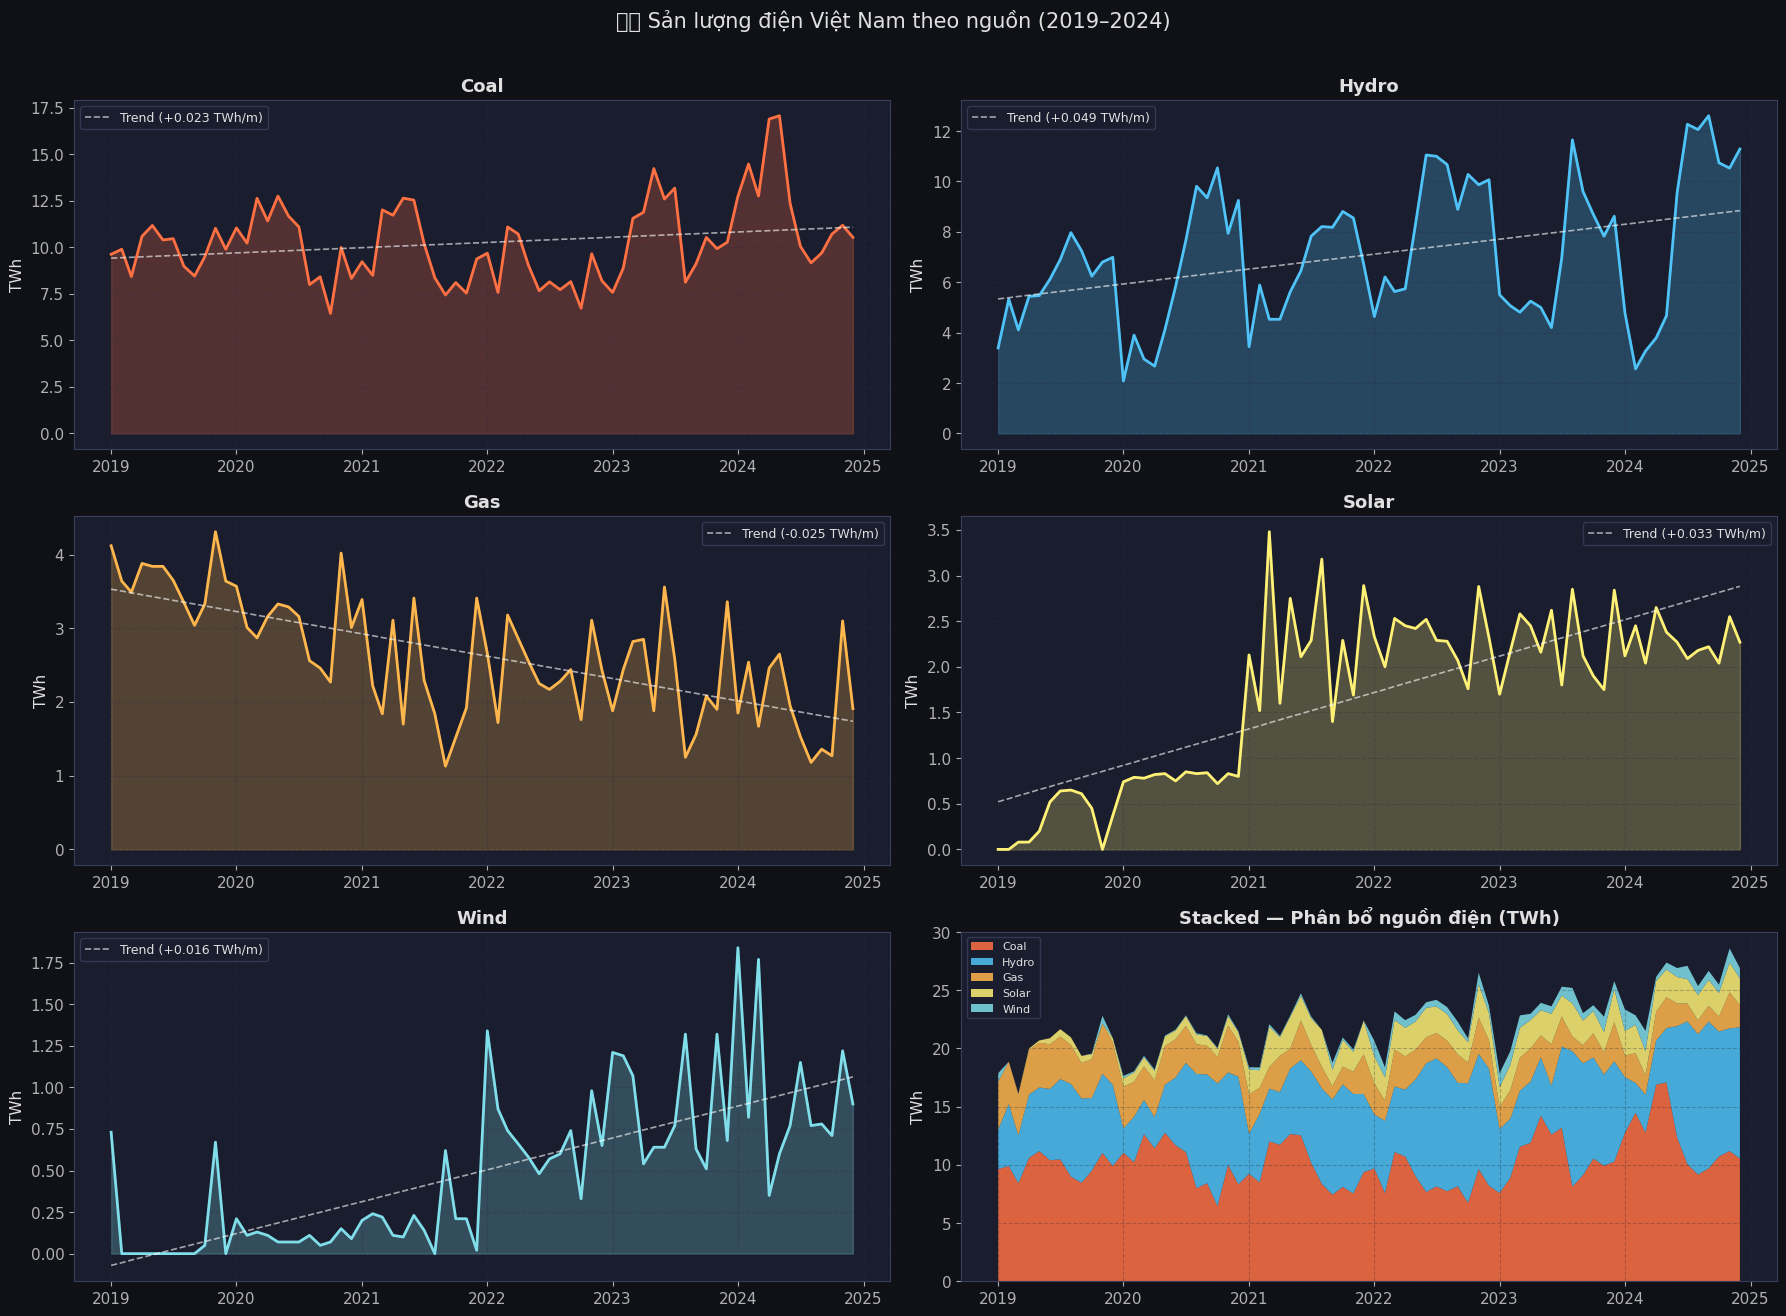

In [22]:
# ── Sản lượng theo thời gian ───────────────────────────────────────────────────
MAIN_SERIES = ['Coal', 'Hydro', 'Gas', 'Solar', 'Wind']

fig, axes = plt.subplots(3, 2, figsize=(18, 13))
axes = axes.flatten()

for i, ser in enumerate(MAIN_SERIES):
    ax = axes[i]
    sub = df[df['series']==ser].sort_values('date')
    color = SERIES_COLORS[ser]
    ax.fill_between(sub['date'], sub['generation_TWh'], alpha=0.25, color=color)
    ax.plot(sub['date'], sub['generation_TWh'], color=color, linewidth=2)

    # Trend line
    from numpy.polynomial.polynomial import polyfit
    x = np.arange(len(sub))
    c, m = polyfit(x, sub['generation_TWh'], 1)
    trend = c + m*x
    ax.plot(sub['date'], trend, '--', color='white', linewidth=1.2, alpha=0.6, label=f'Trend ({m:+.3f} TWh/m)')

    ax.set_title(f'{ser}')
    ax.set_ylabel('TWh')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Stacked area in last panel
ax = axes[5]
pivot = df[df['series'].isin(MAIN_SERIES)].pivot_table(index='date', columns='series', values='generation_TWh')
pivot = pivot[MAIN_SERIES].fillna(0)
ax.stackplot(pivot.index, [pivot[s] for s in MAIN_SERIES],
             labels=MAIN_SERIES, colors=[SERIES_COLORS[s] for s in MAIN_SERIES], alpha=0.85)
ax.set_title('Stacked — Phân bổ nguồn điện (TWh)')
ax.set_ylabel('TWh')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)

plt.suptitle('🇻🇳 Sản lượng điện Việt Nam theo nguồn (2019–2024)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

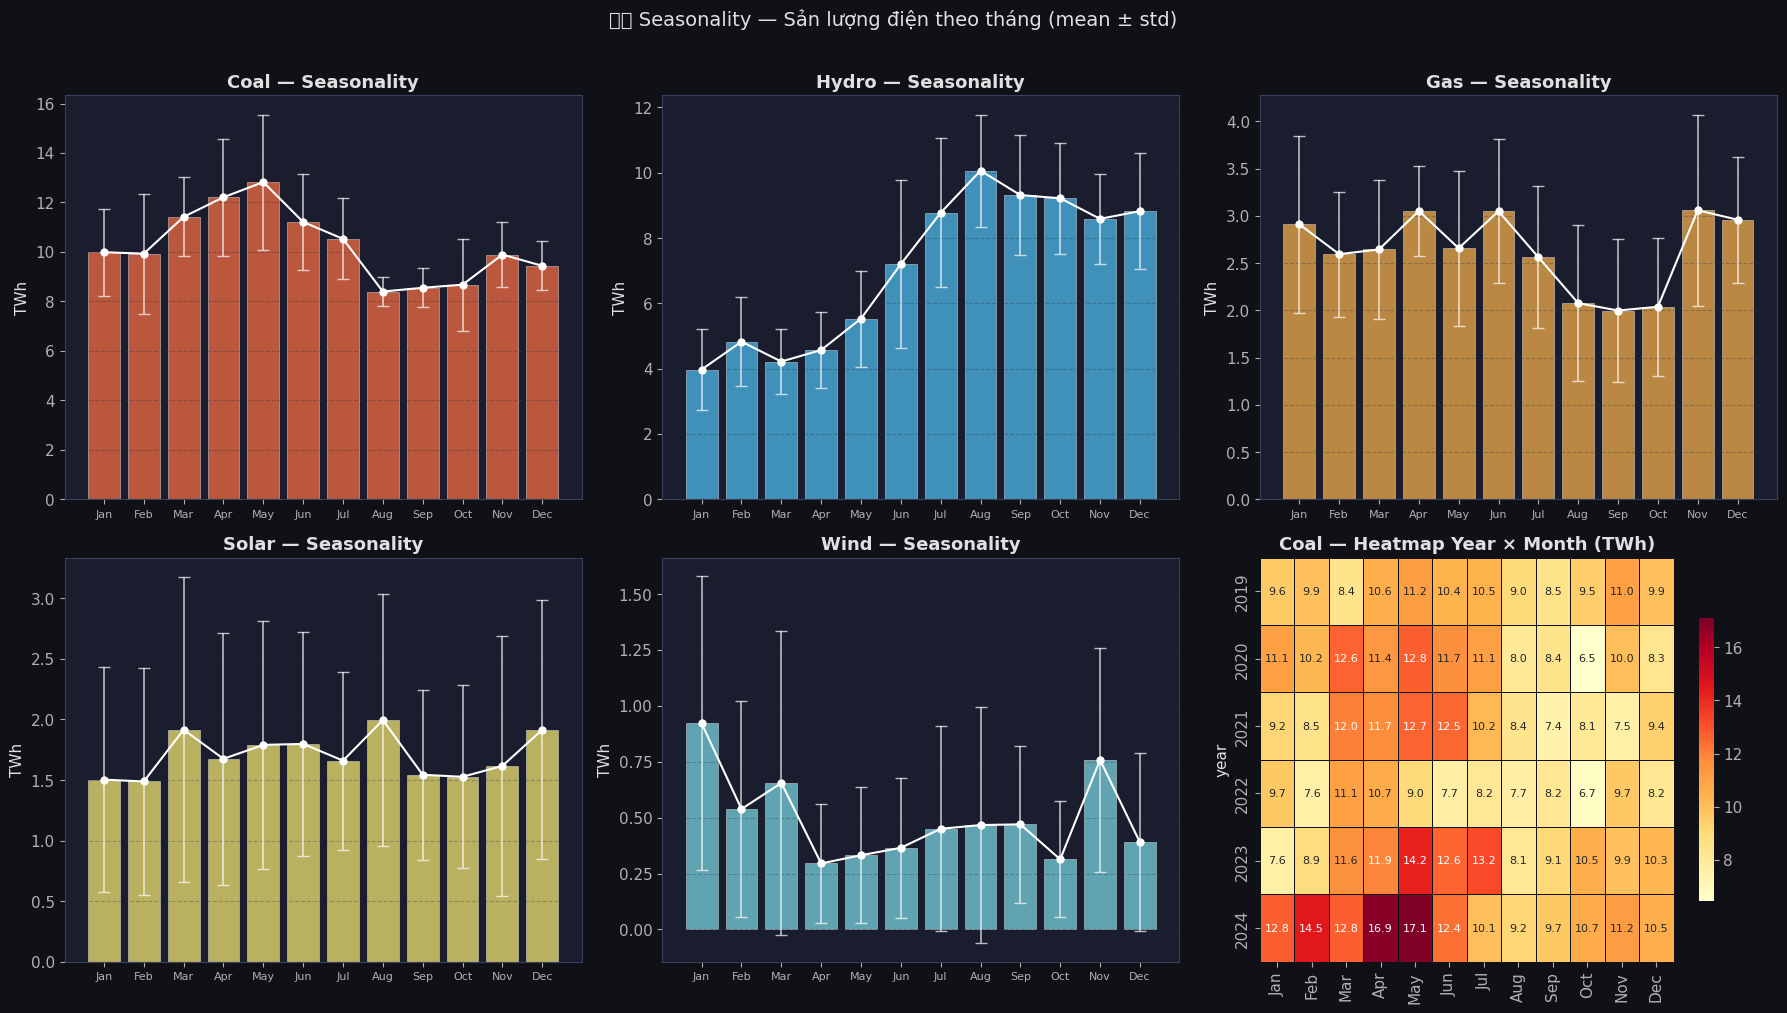


📌 Nhận xét Seasonality:
  • Coal      : Tháng 5-7 cao nhất (mùa khô — Hydro thấp, cần bù than)
  • Hydro     : Tháng 7-9 cao nhất (mùa mưa miền Bắc/Trung)
  • Solar     : Tháng 3-5 cao nhất (nắng miền Nam trước mùa mưa)
  • Wind      : Tháng 10-1 cao nhất (gió mùa Đông Bắc)
  • Gas       : Ổn định, ít mùa vụ


In [23]:
# ── Tính mùa vụ (Seasonality) ─────────────────────────────────────────────────
df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year
months_label = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ser in enumerate(MAIN_SERIES):
    ax = axes[i]
    sub = df[df['series']==ser]
    monthly = sub.groupby('month')['generation_TWh']
    means = monthly.mean()
    stds  = monthly.std()
    color = SERIES_COLORS[ser]

    ax.bar(means.index, means, color=color, alpha=0.7, label='Mean', edgecolor='white', linewidth=0.4)
    ax.errorbar(means.index, means, yerr=stds, fmt='none', capsize=4, color='white', linewidth=1.2, alpha=0.7)
    ax.plot(means.index, means, 'o-', color='white', linewidth=1.5, markersize=5)

    ax.set_xticks(range(1,13))
    ax.set_xticklabels(months_label, fontsize=8)
    ax.set_title(f'{ser} — Seasonality')
    ax.set_ylabel('TWh')
    ax.grid(axis='y', alpha=0.3)

# Heatmap YearXMonth for Coal
ax = axes[5]
for ser in ['Coal', 'Hydro']:
    sub = df[df['series']==ser]
    hm = sub.pivot_table(index='year', columns='month', values='generation_TWh')
    break
# Coal heatmap
sub_coal = df[df['series']=='Coal']
hm = sub_coal.pivot_table(index='year', columns='month', values='generation_TWh')
hm.columns = months_label
sns.heatmap(hm, ax=axes[5], cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#0f1117', annot_kws={'size':8},
            cbar_kws={'shrink':0.7})
axes[5].set_title('Coal — Heatmap Year × Month (TWh)')
axes[5].set_xlabel('')

plt.suptitle('🇻🇳 Seasonality — Sản lượng điện theo tháng (mean ± std)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\n📌 Nhận xét Seasonality:')
print('  • Coal      : Tháng 5-7 cao nhất (mùa khô — Hydro thấp, cần bù than)')
print('  • Hydro     : Tháng 7-9 cao nhất (mùa mưa miền Bắc/Trung)')
print('  • Solar     : Tháng 3-5 cao nhất (nắng miền Nam trước mùa mưa)')
print('  • Wind      : Tháng 10-1 cao nhất (gió mùa Đông Bắc)')
print('  • Gas       : Ổn định, ít mùa vụ')

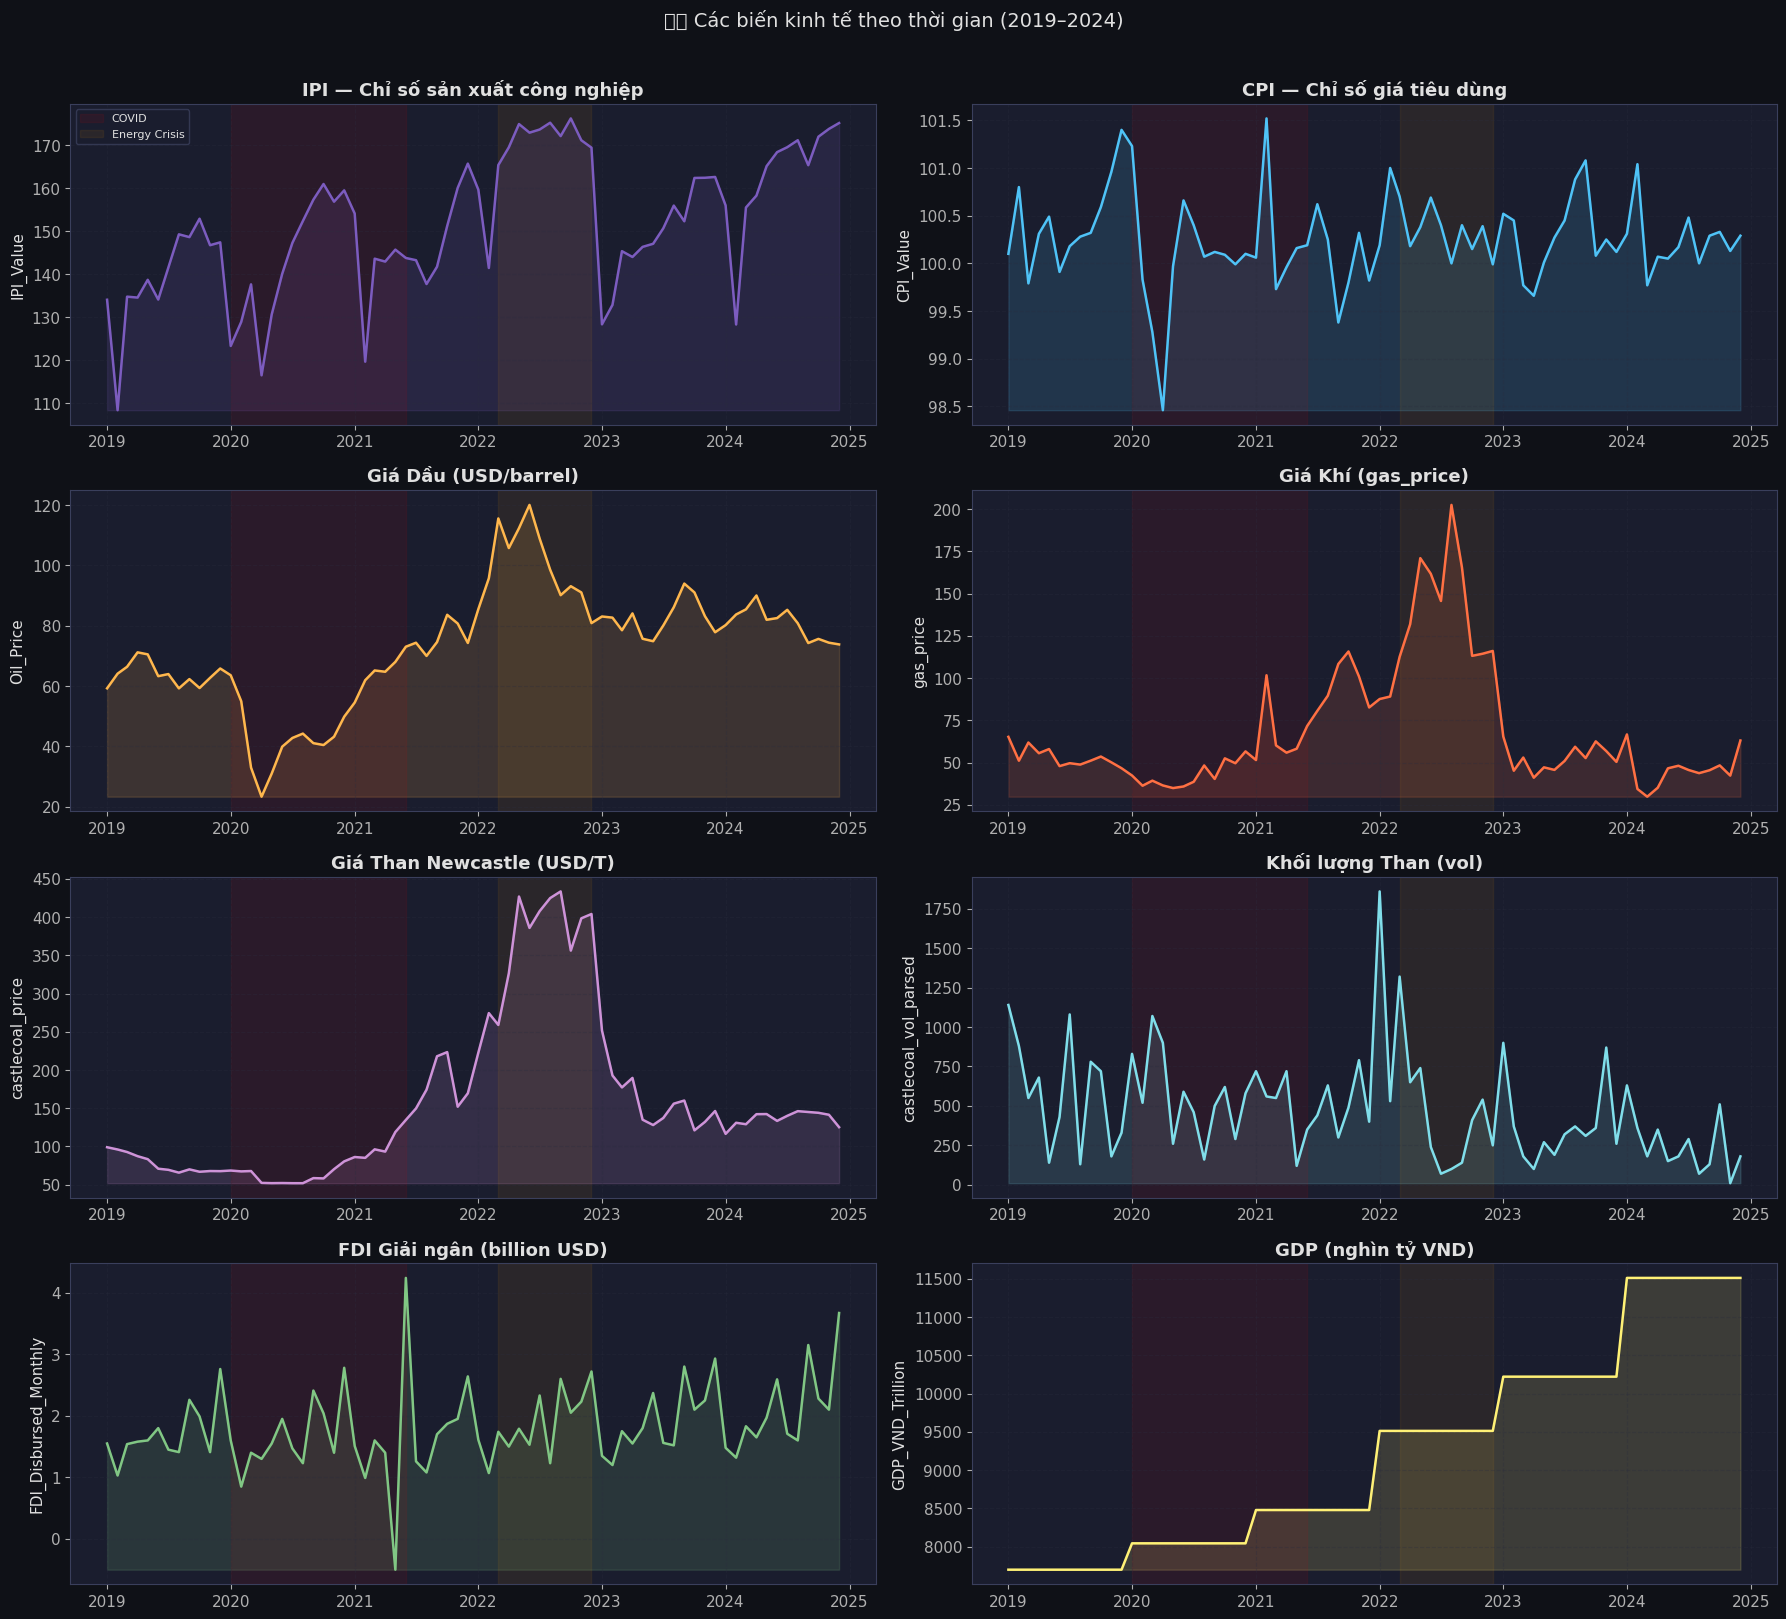

In [24]:
# ── Economic features trend ────────────────────────────────────────────────────
df_coal = df[df['series']=='Coal'].sort_values('date').copy()

eco_plot = [
    ('IPI_Value',                        'IPI — Chỉ số sản xuất công nghiệp',  '#7c5cbf'),
    ('CPI_Value',                        'CPI — Chỉ số giá tiêu dùng',         '#4fc3f7'),
    ('Oil_Price',                        'Giá Dầu (USD/barrel)',                '#ffb74d'),
    ('gas_price',                        'Giá Khí (gas_price)',                 '#ff7043'),
    ('castlecoal_price',                 'Giá Than Newcastle (USD/T)',          '#ce93d8'),
    ('castlecoal_vol_parsed',            'Khối lượng Than (vol)',               '#80deea'),
    ('FDI_Disbursed_Monthly(bilionUSD)', 'FDI Giải ngân (billion USD)',         '#81c784'),
    ('GDP_VND_Trillion',                 'GDP (nghìn tỷ VND)',                  '#fff176'),
]

fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

for i, (col, title, color) in enumerate(eco_plot):
    ax = axes[i]
    ax.plot(df_coal['date'], df_coal[col], color=color, linewidth=1.8)
    ax.fill_between(df_coal['date'], df_coal[col], df_coal[col].min(), alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_ylabel(col.split('(')[0])
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    # Mark COVID and energy crisis
    ax.axvspan(pd.Timestamp('2020-01'), pd.Timestamp('2021-06'), alpha=0.07,
               color='red', label='COVID')
    ax.axvspan(pd.Timestamp('2022-03'), pd.Timestamp('2022-12'), alpha=0.07,
               color='orange', label='Energy Crisis')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('🇻🇳 Các biến kinh tế theo thời gian (2019–2024)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

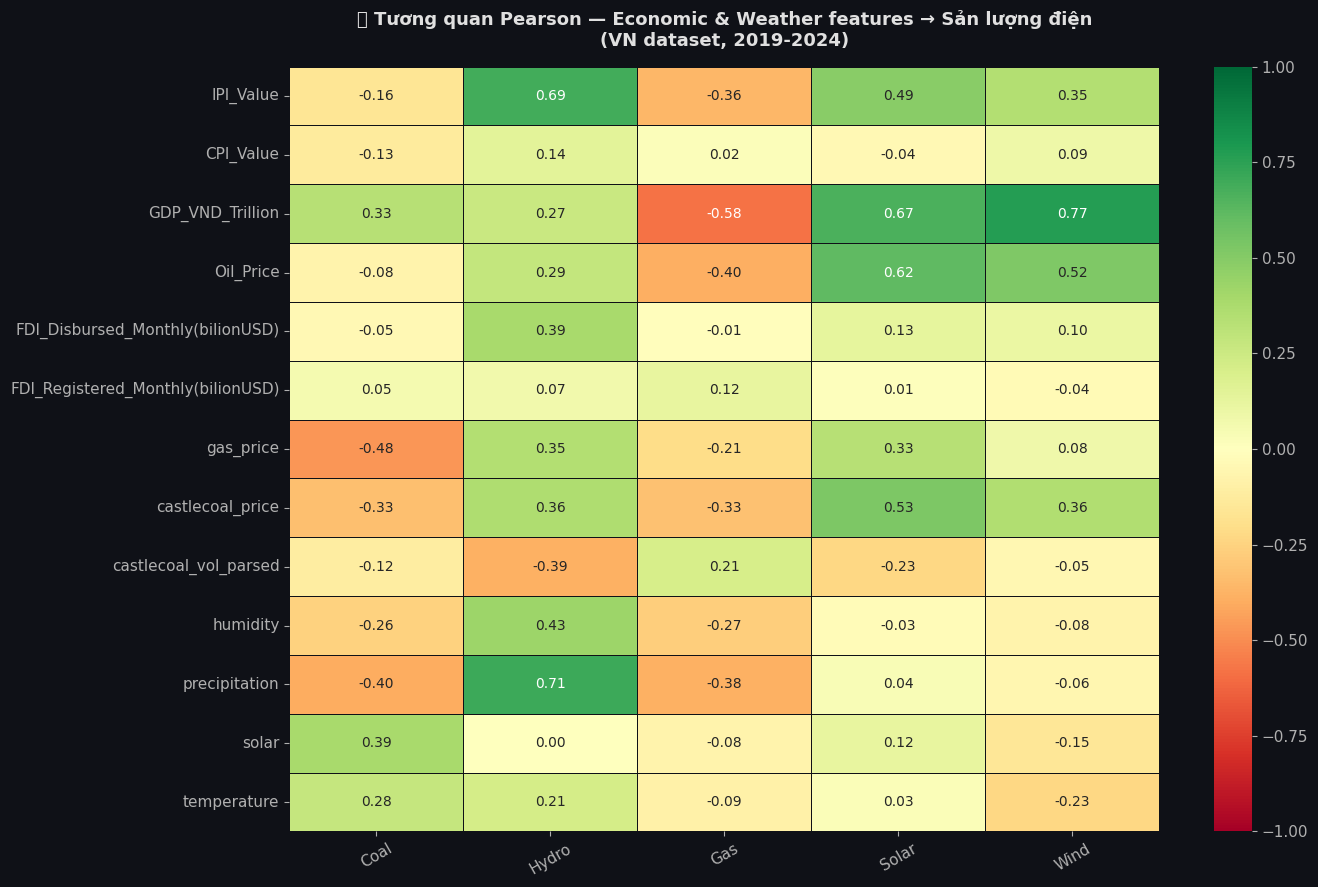


🔝 Top 10 tương quan cao nhất:
   GDP_VND_Trillion                           → Wind             r=+0.772
   precipitation                              → Hydro            r=+0.706
   IPI_Value                                  → Hydro            r=+0.689
   GDP_VND_Trillion                           → Solar            r=+0.668
   Oil_Price                                  → Solar            r=+0.615
   GDP_VND_Trillion                           → Gas              r=-0.585
   castlecoal_price                           → Solar            r=+0.531
   Oil_Price                                  → Wind             r=+0.523
   IPI_Value                                  → Solar            r=+0.487
   gas_price                                  → Coal             r=-0.477


In [25]:
# ── Tương quan kinh tế/thời tiết với sản lượng điện ───────────────────────────
df_pivot = df.pivot_table(index='date', columns='series', values='generation_TWh')
df_full  = df_coal.set_index('date').join(df_pivot, rsuffix='_gen')

feature_cols = eco_cols_num + ['humidity','precipitation','solar','temperature']
target_cols  = MAIN_SERIES

corr_matrix = pd.DataFrame(index=feature_cols, columns=target_cols, dtype=float)
for feat in feature_cols:
    for tgt in target_cols:
        if feat in df_full.columns and tgt in df_full.columns:
            corr_matrix.loc[feat, tgt] = df_full[feat].corr(df_full[tgt])

fig, ax = plt.subplots(figsize=(14, 9))
corr_vals = corr_matrix.astype(float)
sns.heatmap(corr_vals, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='#0f1117',
            annot_kws={'size': 10})
ax.set_title('📊 Tương quan Pearson — Economic & Weather features → Sản lượng điện\n'
             '(VN dataset, 2019-2024)', pad=15)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# Top correlations
print('\n🔝 Top 10 tương quan cao nhất:')
corr_pairs = corr_vals.stack().abs().sort_values(ascending=False)
for (feat, tgt), val in corr_pairs.head(10).items():
    r = corr_vals.loc[feat, tgt]
    print(f'   {feat:<42} → {tgt:<16} r={r:+.3f}')

---
## 4️⃣  Tiền xử lý (Preprocessing)

In [26]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PREPROCESSING PIPELINE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_clean = df.copy()

# ── Step 1: Parse castlecoal_vol ──────────────────────────────────────────────
def parse_k(val):
    if isinstance(val, str) and val.endswith('K'):
        return float(val[:-1]) * 1000
    return float(val)

df_clean['castlecoal_vol'] = df_clean['castlecoal_vol'].apply(parse_k)
print('✅ Step 1: castlecoal_vol parsed → float')

# ── Step 2: Fix FDI âm → clip(0) ─────────────────────────────────────────────
fdi_col = 'FDI_Disbursed_Monthly(bilionUSD)'
n_neg = (df_clean[fdi_col] < 0).sum()
df_clean[fdi_col] = df_clean[fdi_col].clip(lower=0)
print(f'✅ Step 2: FDI_Disbursed clipped — {n_neg} giá trị âm → 0')

# ── Step 3: Loại Total generation (aggregate) ─────────────────────────────────
# Lưu again làm covariate trước khi loại
total_gen = df_clean[df_clean['series']=='Total generation'][['date','generation_TWh']]
total_gen = total_gen.rename(columns={'generation_TWh':'total_generation_TWh'})
df_clean = df_clean[df_clean['series'] != 'Total generation'].copy()
df_clean = df_clean.merge(total_gen, on='date', how='left')
print(f'✅ Step 3: Total generation → covariate "total_generation_TWh", loại khỏi series target')
print(f'   Remaining series: {sorted(df_clean["series"].unique())}')

# ── Step 4: Rename columns cho dễ dùng ───────────────────────────────────────
df_clean = df_clean.rename(columns={
    'FDI_Disbursed_Monthly(bilionUSD)':   'FDI_disbursed',
    'FDI_Registered_Monthly(bilionUSD)':  'FDI_registered',
    'GDP_VND_Trillion':                   'GDP_trillion',
})
print('✅ Step 4: Columns renamed')

# ── Step 5: Drop cột không cần thiết ─────────────────────────────────────────
df_clean = df_clean.drop(columns=['is_aggregate_series'])
print('✅ Step 5: Dropped is_aggregate_series')

print(f'\n📋 Sau preprocessing: {df_clean.shape} — Series: {sorted(df_clean["series"].unique())}')

✅ Step 1: castlecoal_vol parsed → float
✅ Step 2: FDI_Disbursed clipped — 7 giá trị âm → 0
✅ Step 3: Total generation → covariate "total_generation_TWh", loại khỏi series target
   Remaining series: ['Coal', 'Gas', 'Hydro', 'Other fossil', 'Solar', 'Wind']
✅ Step 4: Columns renamed
✅ Step 5: Dropped is_aggregate_series

📋 Sau preprocessing: (432, 21) — Series: ['Coal', 'Gas', 'Hydro', 'Other fossil', 'Solar', 'Wind']


---
## 5️⃣  Feature Engineering

In [27]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# A. TEMPORAL FEATURES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_fe = df_clean.sort_values(['series','date']).copy()

df_fe['month']          = df_fe['date'].dt.month
df_fe['quarter']        = df_fe['date'].dt.quarter
df_fe['year']           = df_fe['date'].dt.year
df_fe['month_sin']      = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos']      = np.cos(2 * np.pi * df_fe['month'] / 12)
df_fe['quarter_sin']    = np.sin(2 * np.pi * df_fe['quarter'] / 4)
df_fe['quarter_cos']    = np.cos(2 * np.pi * df_fe['quarter'] / 4)

# Dry/Rainy season flag (VN specific)
# Mùa khô miền Nam: Nov-Apr; Mùa mưa: May-Oct
df_fe['is_dry_season']  = df_fe['month'].isin([11,12,1,2,3,4]).astype(int)
# Lũ miền Bắc/Trung: Jul-Oct
df_fe['is_flood_season'] = df_fe['month'].isin([7,8,9,10]).astype(int)

# time_idx per series (bắt buộc cho TFT)
df_fe['time_idx'] = df_fe.groupby('series')['date'].rank(method='dense').astype(int) - 1

print('✅ A. Temporal features:')
print('   month, quarter, year, month_sin/cos, quarter_sin/cos')
print('   is_dry_season, is_flood_season, time_idx')

✅ A. Temporal features:
   month, quarter, year, month_sin/cos, quarter_sin/cos
   is_dry_season, is_flood_season, time_idx


In [28]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# B. LAG FEATURES per series
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def add_lag_rolling(grp):
    grp = grp.sort_values('date').copy()
    g   = grp['generation_TWh']

    # ── Lags ──────────────────────────────────────────────────────────────────
    grp['gen_lag_1']  = g.shift(1)   # t-1
    grp['gen_lag_2']  = g.shift(2)   # t-2
    grp['gen_lag_3']  = g.shift(3)   # t-3
    grp['gen_lag_6']  = g.shift(6)   # t-6 (bán niên)
    grp['gen_lag_12'] = g.shift(12)  # t-12 (cùng tháng năm ngoái)

    # ── Rolling stats (shift trước để tránh leakage) ────────────────────────
    g_shift = g.shift(1)
    grp['roll_mean_3']  = g_shift.rolling(3,  min_periods=2).mean()
    grp['roll_mean_6']  = g_shift.rolling(6,  min_periods=3).mean()
    grp['roll_mean_12'] = g_shift.rolling(12, min_periods=6).mean()
    grp['roll_std_3']   = g_shift.rolling(3,  min_periods=2).std()
    grp['roll_std_6']   = g_shift.rolling(6,  min_periods=3).std()
    grp['roll_max_6']   = g_shift.rolling(6,  min_periods=3).max()
    grp['roll_min_6']   = g_shift.rolling(6,  min_periods=3).min()

    # ── YoY Change Rate ──────────────────────────────────────────────────────
    grp['yoy_change']   = (g - g.shift(12)) / (g.shift(12).abs() + 1e-6)
    grp['mom_change']   = (g - g.shift(1))  / (g.shift(1).abs()  + 1e-6)  # Month-over-Month

    # ── Coefficient of variation (volatility index) ──────────────────────────
    grp['roll_cv_6'] = grp['roll_std_6'] / (grp['roll_mean_6'].abs() + 1e-6)

    return grp

print('⏳ Tạo lag & rolling features...')
df_fe = df_fe.groupby('series', group_keys=False).apply(add_lag_rolling)
print('✅ B. Lag & Rolling features:')
print('   gen_lag_1/2/3/6/12')
print('   roll_mean_3/6/12, roll_std_3/6, roll_max_6, roll_min_6')
print('   yoy_change, mom_change, roll_cv_6')

⏳ Tạo lag & rolling features...
✅ B. Lag & Rolling features:
   gen_lag_1/2/3/6/12
   roll_mean_3/6/12, roll_std_3/6, roll_max_6, roll_min_6
   yoy_change, mom_change, roll_cv_6


In [29]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# C. WEATHER FEATURE ENGINEERING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Log precipitation (giảm skewness)
df_fe['log_precipitation'] = np.log1p(df_fe['precipitation'])

# Precipitation lag (nước tích hồ thủy điện)
prec_for_lag = df_fe[df_fe['series']=='Coal'].sort_values('date').set_index('date')[['precipitation']]
prec_lags = pd.DataFrame({
    'prec_lag_1': prec_for_lag['precipitation'].shift(1),
    'prec_lag_2': prec_for_lag['precipitation'].shift(2),
    'prec_lag_3': prec_for_lag['precipitation'].shift(3),
    'prec_roll_3': prec_for_lag['precipitation'].shift(1).rolling(3, min_periods=2).mean(),
}, index=prec_for_lag.index).reset_index()

df_fe = df_fe.merge(prec_lags, on='date', how='left')

# Temperature anomaly (vs monthly average)
monthly_temp = df_fe.groupby('month')['temperature'].mean().to_dict()
df_fe['temp_anomaly'] = df_fe['temperature'] - df_fe['month'].map(monthly_temp)

# Solar normalized 0-1
s_min, s_max = df_fe['solar'].min(), df_fe['solar'].max()
df_fe['solar_norm'] = (df_fe['solar'] - s_min) / (s_max - s_min + 1e-6)

# Humidity anomaly
monthly_hum = df_fe.groupby('month')['humidity'].mean().to_dict()
df_fe['humidity_anomaly'] = df_fe['humidity'] - df_fe['month'].map(monthly_hum)

print('✅ C. Weather features:')
print('   log_precipitation')
print('   prec_lag_1/2/3, prec_roll_3')
print('   temp_anomaly, solar_norm, humidity_anomaly')

✅ C. Weather features:
   log_precipitation
   prec_lag_1/2/3, prec_roll_3
   temp_anomaly, solar_norm, humidity_anomaly


In [30]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# D. ECONOMIC FEATURE ENGINEERING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Log transform cho các feature skewed mạnh
df_fe['log_oil_price']       = np.log(df_fe['Oil_Price'] + 1)
df_fe['log_coal_price']      = np.log(df_fe['castlecoal_price'] + 1)
df_fe['log_gas_price']       = np.log(df_fe['gas_price'] + 1)
df_fe['log_coal_vol']        = np.log(df_fe['castlecoal_vol'] + 1)
df_fe['log_gdp']             = np.log(df_fe['GDP_trillion'] + 1)

# Economic lags (kinh tế tác động trễ lên điện)
# Tính trên coal series (same value for all series at same date)
econ_df = df_fe[df_fe['series']=='Coal'].sort_values('date').set_index('date')
econ_lag_cols = ['Oil_Price','gas_price','castlecoal_price','IPI_Value','GDP_trillion']
econ_lags_dict = {'date': econ_df.index}

for col in econ_lag_cols:
    series_econ = econ_df[col]
    econ_lags_dict[f'{col}_lag1']     = series_econ.shift(1).values
    econ_lags_dict[f'{col}_lag3']     = series_econ.shift(3).values
    econ_lags_dict[f'{col}_roll3']    = series_econ.shift(1).rolling(3, min_periods=2).mean().values
    econ_lags_dict[f'{col}_yoy']      = ((series_econ - series_econ.shift(12)) /
                                          (series_econ.shift(12).abs() + 1e-6)).values

econ_lags_df = pd.DataFrame(econ_lags_dict)
df_fe = df_fe.merge(econ_lags_df, on='date', how='left')

# Coal-elasticity ratio: IPI growth should drive electricity demand
df_fe['ipi_mom'] = df_fe['IPI_Value'] / (df_fe['IPI_Value'].shift(1) + 1e-6)

# log_target
df_fe['log_generation'] = np.log1p(df_fe['generation_TWh'])

print('✅ D. Economic features:')
print('   log_oil_price, log_coal_price, log_gas_price, log_coal_vol, log_gdp')
print('   [Oil_Price/gas_price/castlecoal_price/IPI/GDP]_lag1/lag3/roll3/yoy')
print('   ipi_mom (month-over-month IPI ratio)')
print('   log_generation (log-transformed target)')
print(f'\n📋 Total features: {df_fe.shape[1]} columns (từ 18 gốc)')

✅ D. Economic features:
   log_oil_price, log_coal_price, log_gas_price, log_coal_vol, log_gdp
   [Oil_Price/gas_price/castlecoal_price/IPI/GDP]_lag1/lag3/roll3/yoy
   ipi_mom (month-over-month IPI ratio)
   log_generation (log-transformed target)

📋 Total features: 79 columns (từ 18 gốc)


In [31]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# E. CROSS-SERIES FEATURES (tỷ lệ giữa các nguồn điện)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Pivot để tính ratio
pivot_gen = df_clean[df_clean['series'].isin(['Coal','Gas','Hydro','Solar','Wind'])]\
    .pivot_table(index='date', columns='series', values='generation_TWh')

pivot_gen['total']          = pivot_gen.sum(axis=1)
pivot_gen['coal_ratio']     = pivot_gen['Coal']  / (pivot_gen['total'] + 1e-6)
pivot_gen['hydro_ratio']    = pivot_gen['Hydro'] / (pivot_gen['total'] + 1e-6)
pivot_gen['fossil_ratio']   = (pivot_gen['Coal'] + pivot_gen['Gas']) / (pivot_gen['total'] + 1e-6)
pivot_gen['renew_ratio']    = (pivot_gen['Hydro'] + pivot_gen['Solar'] + pivot_gen['Wind']) / (pivot_gen['total'] + 1e-6)
pivot_gen['coal_hydro_sub'] = pivot_gen['Coal'] - pivot_gen['Hydro']  # substitution signal
pivot_gen['solar_lag1']     = pivot_gen['Solar'].shift(1)
pivot_gen['hydro_lag1']     = pivot_gen['Hydro'].shift(1)
pivot_gen['coal_lag1']      = pivot_gen['Coal'].shift(1)

cross_cols = ['coal_ratio','hydro_ratio','fossil_ratio','renew_ratio',
              'coal_hydro_sub','solar_lag1','hydro_lag1','coal_lag1']
cross_df   = pivot_gen[cross_cols].reset_index()

df_fe = df_fe.merge(cross_df, on='date', how='left')

print('✅ E. Cross-series features:')
print('   coal_ratio, hydro_ratio, fossil_ratio, renew_ratio')
print('   coal_hydro_sub (substitution between coal and hydro)')
print('   solar_lag1, hydro_lag1, coal_lag1 (other series lagged)')

✅ E. Cross-series features:
   coal_ratio, hydro_ratio, fossil_ratio, renew_ratio
   coal_hydro_sub (substitution between coal and hydro)
   solar_lag1, hydro_lag1, coal_lag1 (other series lagged)


---
## 6️⃣  Kiểm tra & Visualize Features mới

In [32]:
# ── Kiểm tra NaN sau FE ───────────────────────────────────────────────────────
print('📊 Missing values sau Feature Engineering:')
nan_counts = df_fe.isnull().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
for col, n in nan_counts.items():
    pct = n / len(df_fe) * 100
    print(f'  {col:<45}: {n:4d} ({pct:.1f}%)')

print()
print('📌 NaN do lag features — đầu mỗi chuỗi không có giá trị lịch sử. Bình thường!')
print(f'   TFT xử lý bằng allow_missing_timesteps=True hoặc fill_value hợp lý')
print()
print(f'📋 Final shape: {df_fe.shape}')
print(f'   Columns ({df_fe.shape[1]}): {df_fe.columns.tolist()}')

📊 Missing values sau Feature Engineering:
  gen_lag_12                                   :   72 (16.7%)
  Oil_Price_yoy                                :   72 (16.7%)
  yoy_change                                   :   72 (16.7%)
  castlecoal_price_yoy                         :   72 (16.7%)
  gas_price_yoy                                :   72 (16.7%)
  GDP_trillion_yoy                             :   72 (16.7%)
  IPI_Value_yoy                                :   72 (16.7%)
  gen_lag_6                                    :   36 (8.3%)
  roll_mean_12                                 :   36 (8.3%)
  roll_max_6                                   :   18 (4.2%)
  roll_std_6                                   :   18 (4.2%)
  IPI_Value_lag3                               :   18 (4.2%)
  gas_price_lag3                               :   18 (4.2%)
  castlecoal_price_lag3                        :   18 (4.2%)
  GDP_trillion_lag3                            :   18 (4.2%)
  roll_mean_6                       

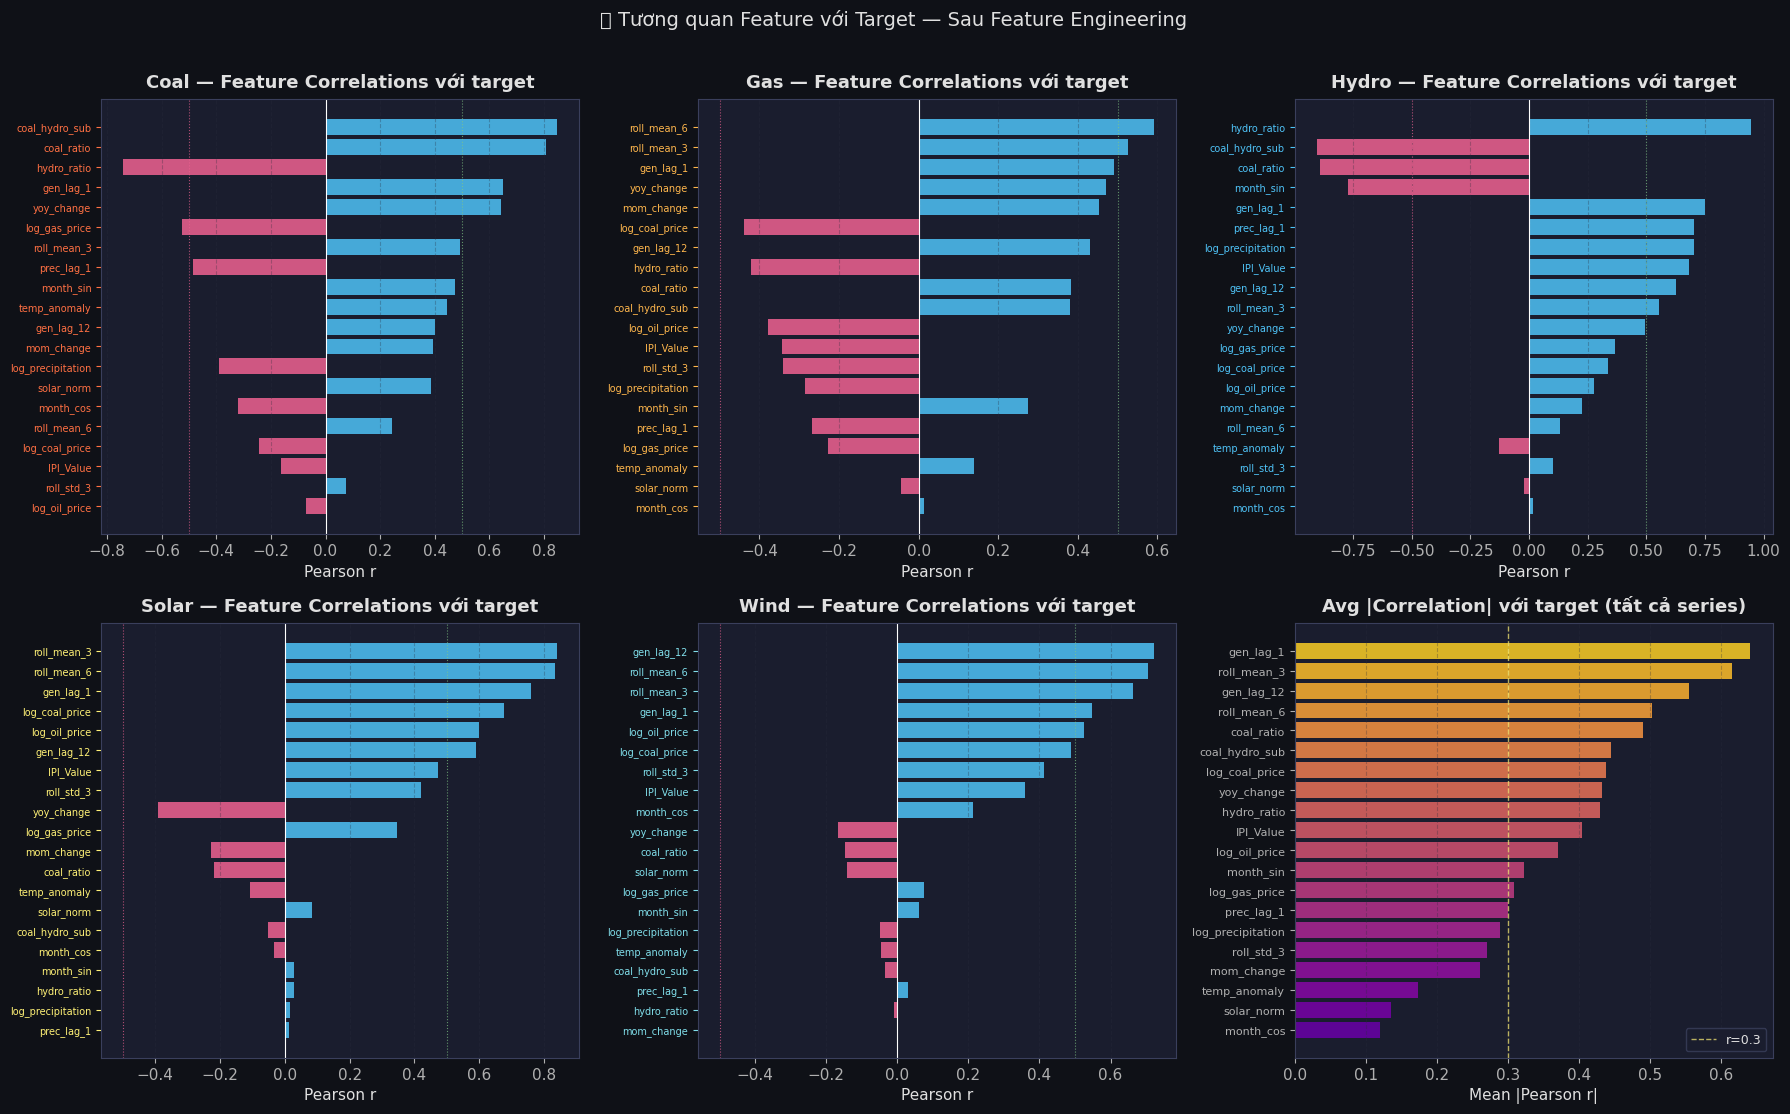

In [33]:
# ── Feature correlation với target theo từng series ───────────────────────────
NEW_FEATURES = [
    'gen_lag_1','gen_lag_12','roll_mean_3','roll_mean_6','roll_std_3',
    'yoy_change','mom_change','temp_anomaly','log_precipitation','prec_lag_1',
    'solar_norm','log_coal_price','log_oil_price','log_gas_price','IPI_Value',
    'month_sin','month_cos','coal_ratio','hydro_ratio','coal_hydro_sub'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

series_list = ['Coal','Gas','Hydro','Solar','Wind']
for i, ser in enumerate(series_list):
    ax = axes[i]
    sub = df_fe[df_fe['series']==ser].dropna(subset=['gen_lag_1'])
    feats_avail = [f for f in NEW_FEATURES if f in sub.columns]
    corrs = sub[feats_avail].corrwith(sub['generation_TWh'])
    corrs = corrs.dropna().sort_values(key=abs, ascending=True)

    colors = ['#f06292' if v < 0 else '#4fc3f7' for v in corrs.values]
    ax.barh(range(len(corrs)), corrs.values, color=colors, alpha=0.85)
    ax.set_yticks(range(len(corrs)))
    ax.set_yticklabels(corrs.index, fontsize=7)
    ax.axvline(0, color='white', linewidth=0.8)
    ax.axvline(0.5,  color='#81c784', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.axvline(-0.5, color='#f06292', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.set_title(f'{ser} — Feature Correlations với target', pad=8)
    ax.set_xlabel('Pearson r')
    ax.grid(axis='x', alpha=0.3)
    color_patch = SERIES_COLORS.get(ser, '#7c5cbf')
    ax.tick_params(axis='y', colors=color_patch)

# Summary in last panel
ax = axes[5]
all_corr = {}
for ser in series_list:
    sub = df_fe[df_fe['series']==ser].dropna(subset=['gen_lag_1'])
    feats_avail = [f for f in NEW_FEATURES if f in sub.columns]
    c = sub[feats_avail].corrwith(sub['generation_TWh']).abs()
    all_corr[ser] = c

avg_corr = pd.DataFrame(all_corr).mean(axis=1).sort_values(ascending=True)
colors_avg = plt.cm.plasma(np.linspace(0.2, 0.9, len(avg_corr)))
ax.barh(range(len(avg_corr)), avg_corr.values, color=colors_avg, alpha=0.85)
ax.set_yticks(range(len(avg_corr)))
ax.set_yticklabels(avg_corr.index, fontsize=8)
ax.set_title('Avg |Correlation| với target (tất cả series)', pad=8)
ax.set_xlabel('Mean |Pearson r|')
ax.axvline(0.3, color='#fff176', linewidth=1, linestyle='--', alpha=0.7, label='r=0.3')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.suptitle('📈 Tương quan Feature với Target — Sau Feature Engineering', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

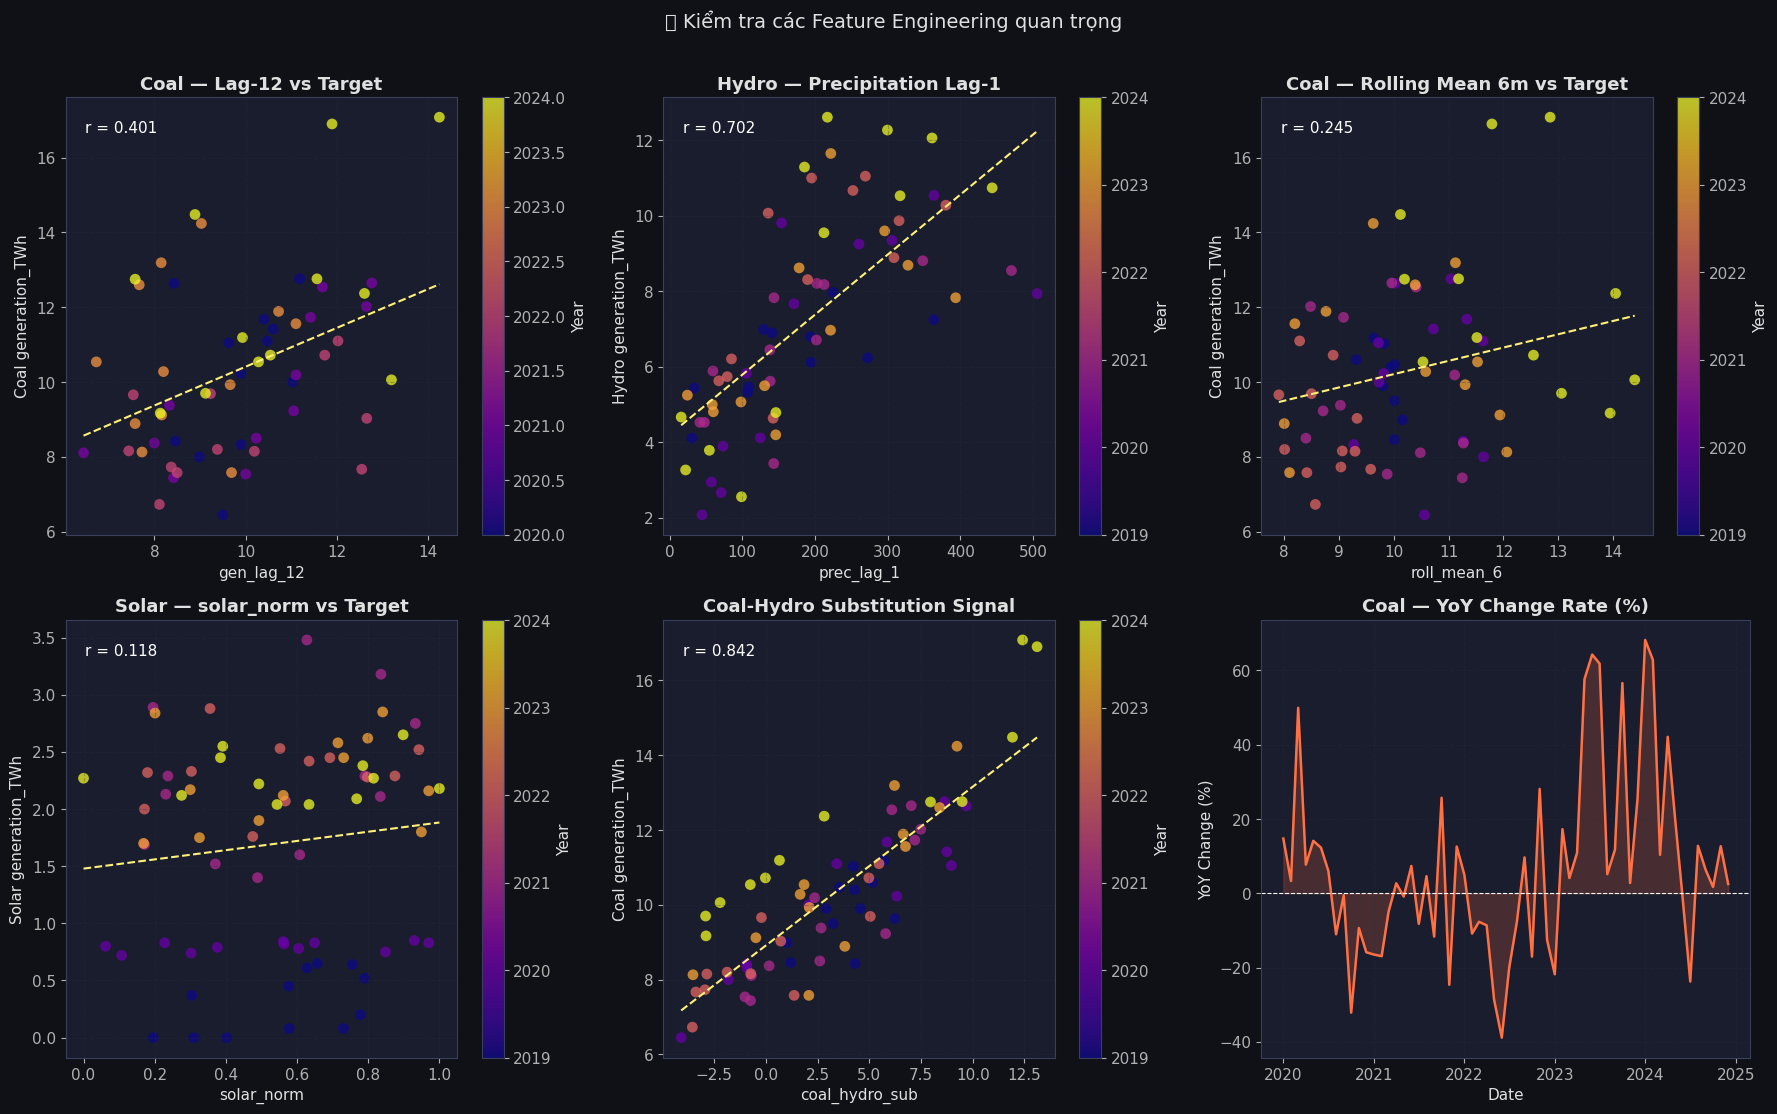

In [34]:
# ── Lag feature visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

plot_items = [
    ('Coal',  'gen_lag_12',       'Coal — Lag-12 vs Target',           '#ff7043'),
    ('Hydro', 'prec_lag_1',       'Hydro — Precipitation Lag-1',       '#4fc3f7'),
    ('Coal',  'roll_mean_6',      'Coal — Rolling Mean 6m vs Target',  '#ff7043'),
    ('Solar', 'solar_norm',       'Solar — solar_norm vs Target',      '#fff176'),
    ('Coal',  'coal_hydro_sub',   'Coal-Hydro Substitution Signal',    '#ff7043'),
    ('Coal',  'yoy_change',       'Coal — YoY Change Rate (%)',        '#ff7043'),
]

for i, (ser, feat, title, color) in enumerate(plot_items):
    ax = axes[i]
    sub = df_fe[df_fe['series']==ser].dropna(subset=[feat,'generation_TWh'])
    if feat == 'yoy_change':
        ax.plot(sub['date'], sub[feat]*100, color=color, linewidth=1.8)
        ax.fill_between(sub['date'], sub[feat]*100, 0, alpha=0.2, color=color)
        ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
        ax.set_ylabel('YoY Change (%)')
        ax.set_xlabel('Date')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    else:
        sc = ax.scatter(sub[feat], sub['generation_TWh'],
                        c=sub['date'].dt.year, cmap='plasma', alpha=0.75, s=60, edgecolors='none')
        plt.colorbar(sc, ax=ax, label='Year')
        if len(sub) > 2:
            x_c = sub[feat].fillna(0)
            y_c = sub['generation_TWh'].fillna(0)
            m, b = np.polyfit(x_c, y_c, 1)
            xl = np.linspace(x_c.min(), x_c.max(), 50)
            ax.plot(xl, m*xl + b, '--', color='#fff176', linewidth=1.5)
            r = sub[feat].corr(sub['generation_TWh'])
            ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes,
                    fontsize=11, color='white')
        ax.set_xlabel(feat)
        ax.set_ylabel(f'{ser} generation_TWh')
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.suptitle('🔍 Kiểm tra các Feature Engineering quan trọng', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 7️⃣  Cấu hình TFT TimeSeriesDataSet & Lưu file

In [35]:
# ── TFT column mapping ─────────────────────────────────────────────────────────
print('╔══════════════════════════════════════════════════════════════════════════╗')
print('║         PHÂN LOẠI FEATURES CHO TimeSeriesDataSet                        ║')
print('╠══════════════════════════════════════════════════════════════════════════╣')

TFT_CONFIG = {
    'time_idx': 'time_idx',
    'target': 'generation_TWh',
    'group_ids': ['entity', 'series'],

    # Biết trước cả tương lai (lịch, dự báo thời tiết)
    'time_varying_known_reals': [
        'time_idx', 'month', 'quarter', 'year',
        'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos',
        'is_dry_season', 'is_flood_season',
        'solar',           # bức xạ = dự báo được
        'temperature',     # nhiệt độ = dự báo được
        'humidity',        # độ ẩm = dự báo được
    ],

    # Chỉ biết từ lịch sử (không biết tương lai)
    'time_varying_unknown_reals': [
        'generation_TWh',  # target autoregressive
        # Lags
        'gen_lag_1', 'gen_lag_2', 'gen_lag_3', 'gen_lag_6', 'gen_lag_12',
        # Rolling
        'roll_mean_3', 'roll_mean_6', 'roll_mean_12',
        'roll_std_3', 'roll_std_6', 'roll_max_6', 'roll_min_6',
        'yoy_change', 'mom_change', 'roll_cv_6',
        # Weather lag
        'precipitation', 'log_precipitation',
        'prec_lag_1', 'prec_lag_2', 'prec_lag_3', 'prec_roll_3',
        'temp_anomaly', 'solar_norm', 'humidity_anomaly',
        # Economic
        'Oil_Price', 'log_oil_price', 'gas_price', 'log_gas_price',
        'castlecoal_price', 'log_coal_price',
        'castlecoal_vol', 'log_coal_vol',
        'IPI_Value', 'CPI_Value', 'GDP_trillion', 'log_gdp',
        'FDI_disbursed', 'FDI_registered',
        # Economic lags
        'Oil_Price_lag1', 'gas_price_lag1', 'castlecoal_price_lag1',
        'IPI_Value_lag1', 'IPI_Value_yoy',
        # Cross-series
        'coal_ratio', 'hydro_ratio', 'fossil_ratio', 'renew_ratio',
        'coal_hydro_sub', 'solar_lag1', 'hydro_lag1', 'coal_lag1',
        'total_generation_TWh',
    ],

    # Static (không đổi theo thời gian)
    'static_categoricals': ['entity', 'series'],
    'static_reals': [],
}

for key, val in TFT_CONFIG.items():
    if isinstance(val, list):
        print(f'  {key} ({len(val)}):')
        for v in val:
            print(f'    - {v}')
    else:
        print(f'  {key}: {val}')
print('╚══════════════════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════════════════╗
║         PHÂN LOẠI FEATURES CHO TimeSeriesDataSet                        ║
╠══════════════════════════════════════════════════════════════════════════╣
  time_idx: time_idx
  target: generation_TWh
  group_ids (2):
    - entity
    - series
  time_varying_known_reals (13):
    - time_idx
    - month
    - quarter
    - year
    - month_sin
    - month_cos
    - quarter_sin
    - quarter_cos
    - is_dry_season
    - is_flood_season
    - solar
    - temperature
    - humidity
  time_varying_unknown_reals (53):
    - generation_TWh
    - gen_lag_1
    - gen_lag_2
    - gen_lag_3
    - gen_lag_6
    - gen_lag_12
    - roll_mean_3
    - roll_mean_6
    - roll_mean_12
    - roll_std_3
    - roll_std_6
    - roll_max_6
    - roll_min_6
    - yoy_change
    - mom_change
    - roll_cv_6
    - precipitation
    - log_precipitation
    - prec_lag_1
    - prec_lag_2
    - prec_lag_3
    - prec_roll_3
    - temp_anomaly

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FINAL PRODUCTION PREPROCESSING (ZERO LEAKAGE)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import os

# Use absolute paths to be safe when running from different locations
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH = os.path.join(BASE_DIR, '..', 'data', 'processed', 'VN_data', 'full_vietnam_monthly_merger.csv')
OUT_PATH  = os.path.join(BASE_DIR, '..', 'data', 'processed', 'VN_data', 'vn_tft_ready.csv')

print(f"🚀 Starting Production Preprocessing...")
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

# ── Step 1: Fix Data Types & Outliers ────────────────────────────────────────
def parse_k(val):
    if isinstance(val, str) and val.endswith('K'):
        return float(val[:-1]) * 1000
    return float(val)

df['castlecoal_vol'] = df['castlecoal_vol'].apply(parse_k)
df['FDI_Disbursed_Monthly(bilionUSD)'] = df['FDI_Disbursed_Monthly(bilionUSD)'].clip(lower=0)

# ── Step 2: Extract Total gen as covariate ────────────────────────────────────
total_gen = df[df['series']=='Total generation'][['date','generation_TWh']]
total_gen = total_gen.rename(columns={'generation_TWh':'total_generation_TWh'})
df_clean  = df[df['series'] != 'Total generation'].copy()
df_clean  = df_clean.merge(total_gen, on='date', how='left')
df_clean  = df_clean.rename(columns={
    'FDI_Disbursed_Monthly(bilionUSD)':  'FDI_disbursed',
    'FDI_Registered_Monthly(bilionUSD)': 'FDI_registered',
    'GDP_VND_Trillion':                  'GDP_trillion',
})
if 'is_aggregate_series' in df_clean.columns: df_clean = df_clean.drop(columns=['is_aggregate_series'])

# ── Step 3: Feature Engineering ───────────────────────────────────────────────
df_fe = df_clean.sort_values(['series','date']).copy()
df_fe['month'] = df_fe['date'].dt.month
df_fe['year']  = df_fe['date'].dt.year
df_fe['time_idx'] = df_fe.groupby('series')['date'].rank(method='dense').astype(int) - 1

def add_lag_rolling(grp):
    grp = grp.sort_values('date').copy()
    g   = grp['generation_TWh']
    grp['gen_lag_1']    = g.shift(1)
    grp['gen_lag_2']    = g.shift(2)
    grp['gen_lag_3']    = g.shift(3)
    grp['gen_lag_12']   = g.shift(12)
    g_s = g.shift(1)
    grp['roll_mean_6']  = g_s.rolling(6,  min_periods=3).mean()
    grp['roll_std_6']   = g_s.rolling(6,  min_periods=3).std()
    grp['yoy_change']   = (g - g.shift(12)) / (g.shift(12).abs() + 1e-6)
    return grp

df_fe = df_fe.groupby('series', group_keys=False).apply(add_lag_rolling)

# ── Step 4: Weather Shifting (LEAKAGE PREVENTION) ─────────────────────────────
weather_cols = ['temperature', 'solar', 'humidity', 'precipitation']
for col in weather_cols:
    df_fe[col] = df_fe.groupby('series')[col].shift(1)
    
df_fe['precip_roll6'] = df_fe.groupby('series')['precipitation'].transform(lambda x: x.rolling(6, min_periods=3).mean())
print("✅ Weather shifted by 1 month to prevent leakage.")

# ── Step 5: Cross-Series & Fill NaN ───────────────────────────────────────────
pivot_gen = df_clean.pivot_table(index='date', columns='series', values='generation_TWh')
pivot_gen['total'] = pivot_gen.sum(axis=1)
pivot_gen['coal_ratio'] = (pivot_gen['Coal'] / (pivot_gen['total'] + 1e-6)).shift(1)
df_fe = df_fe.merge(pivot_gen[['coal_ratio']].reset_index(), on='date', how='left')

lag_cols = [c for c in df_fe.columns if 'lag' in c or 'roll' in c or 'yoy' in c]
df_fe[lag_cols] = df_fe.groupby('series')[lag_cols].transform(lambda x: x.fillna(0))

df_fe.to_csv(OUT_PATH, index=False)
print(f"💾 Production data saved: {OUT_PATH}")
print(f"   Shape: {df_fe.shape} | Series: {sorted(df_fe['series'].unique())}")